# Lecture 5 — Visualization with Seaborn

**Credits**:

This notebook is modified from the materials provided with [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas.

Modified for the course *Python Programming for Business Intelligence* by Sippo Rossi.
___

Matplotlib has proven to be a popular visualization tool, but even avid users will admit it often leaves much to be desired.
Seaborn provides a high-level interface for drawing attractive and informative statistical graphics. It is built on top of Matplotlib and integrates closely with pandas data structures.

In this notebook, we will cover the most common and generally useful types of visualizations: scatter plots, histograms, density plots, line charts, bar charts, boxplots and heatmaps.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # Apply seaborn's default theme to all plots

## Seaborn versus Matplotlib

To illustrate the difference, let's create some random walk data and plot it first with plain Matplotlib, then with Seaborn's styling applied.

In [3]:
# Create some random walk data
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

Plotting with Matplotlib defaults:

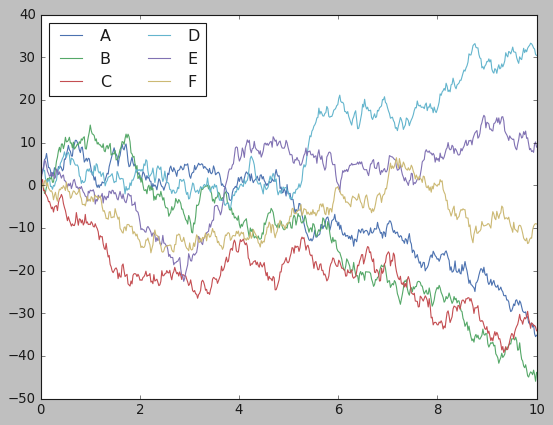

In [5]:
plt.style.use('classic')  # Use the old Matplotlib style for comparison
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left');

Now with Seaborn's default theme applied:

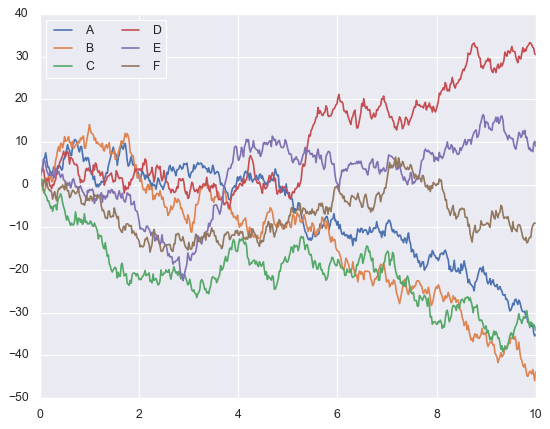

In [6]:
sns.set_theme()  # Re-apply seaborn theme
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left');

The same code produces a much more visually appealing plot with Seaborn's styling. The background grid, color palette and overall aesthetics are all improved.

## Loading datasets

Seaborn comes with several built-in datasets that are useful for learning and demonstration. We will primarily use the **penguins** and **flights** datasets in this notebook.

In [7]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [8]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Scatter plots

Scatter plots are useful for inspecting bivariate data or pairs of variables. They can reveal clusters, or whether there is a positive, negative or no correlation between variables.

In seaborn, ``sns.scatterplot()`` is the main function for scatter plots.

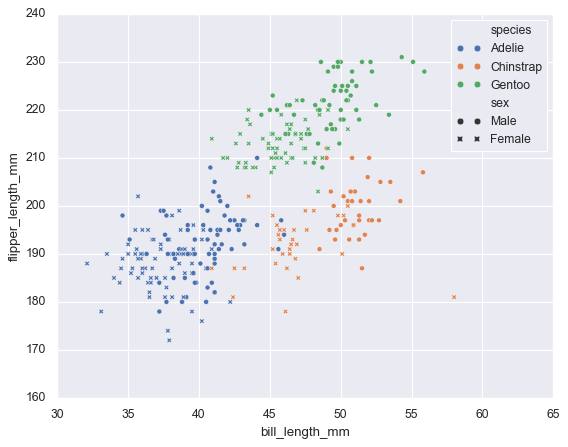

In [9]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='flipper_length_mm',
                hue='species', style='sex');

The ``hue`` parameter colors points by a categorical variable, and ``style`` changes the marker shape. This makes it easy to distinguish groups within the data.

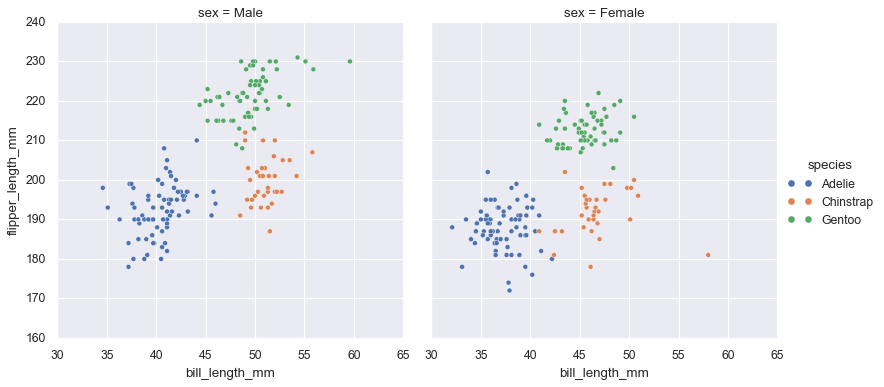

In [10]:
# relplot provides a figure-level interface and supports faceting
sns.relplot(data=penguins, x='bill_length_mm', y='flipper_length_mm',
            hue='species', col='sex', kind='scatter');

### Pair plots

When you want to explore correlations between all pairs of numerical variables, ``sns.pairplot()`` creates a grid of scatter plots with histograms on the diagonal.

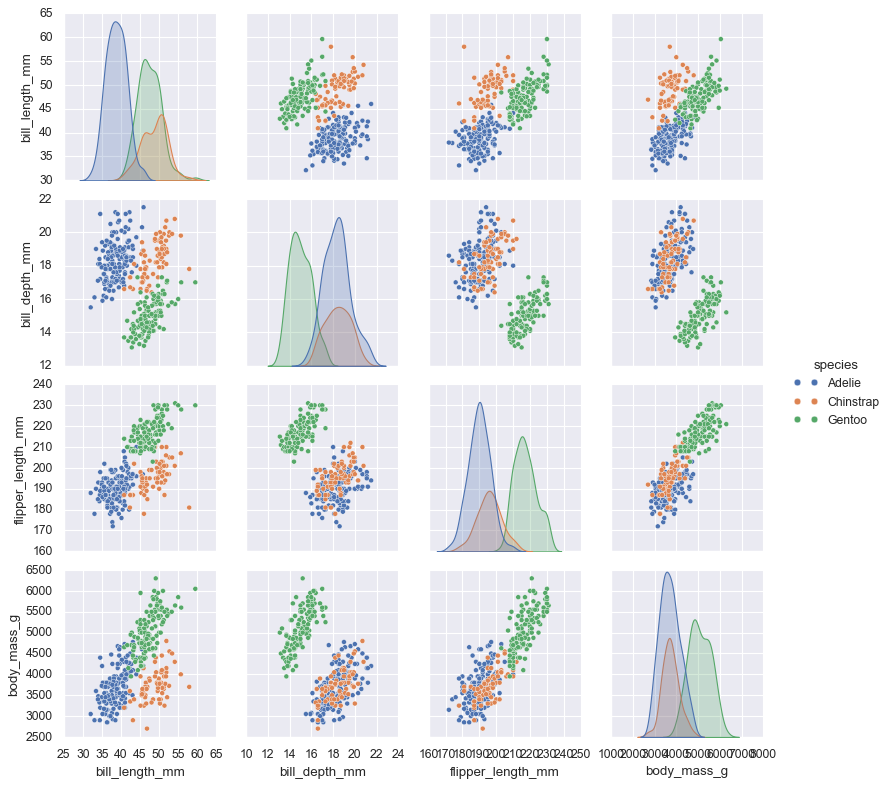

In [11]:
sns.pairplot(penguins, hue='species', height=2.5);

## Histograms

Histograms help understand how variables are distributed. The main parameter is ``bins`` which determines how the data is divided. The size of the bins can significantly affect the interpretation of the plot.

In seaborn, ``sns.histplot()`` is the recommended function for histograms.

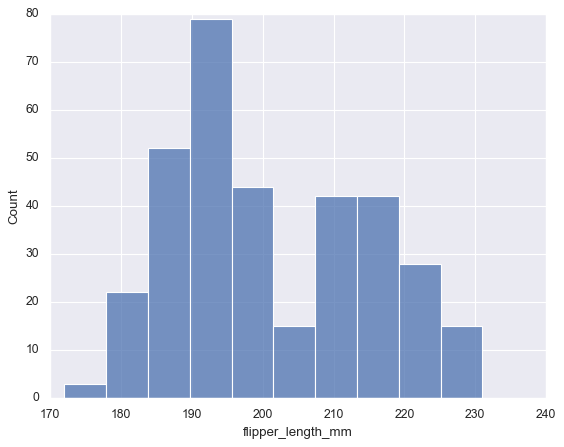

In [12]:
sns.histplot(data=penguins, x='flipper_length_mm');

Let's see how different bin sizes affect the appearance of the same data:

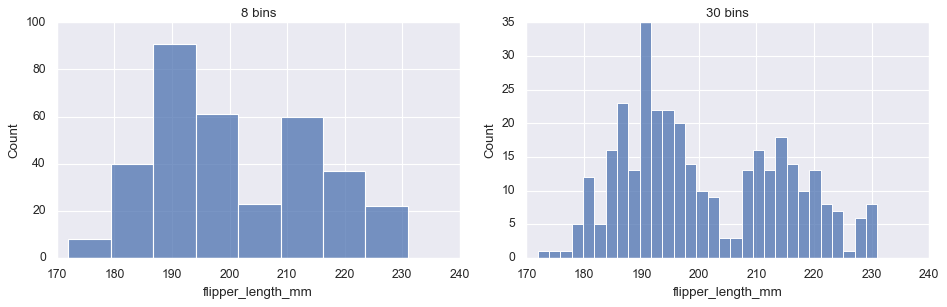

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=penguins, x='flipper_length_mm', bins=8, ax=axes[0])
axes[0].set_title('8 bins')

sns.histplot(data=penguins, x='flipper_length_mm', bins=30, ax=axes[1])
axes[1].set_title('30 bins')

plt.tight_layout();

## Density plots (KDE)

Density plots provide a smooth estimate of the distribution using kernel density estimation (KDE). They avoid the bin size issues of histograms but are slightly more difficult to interpret.

In seaborn, ``sns.kdeplot()`` draws density curves.

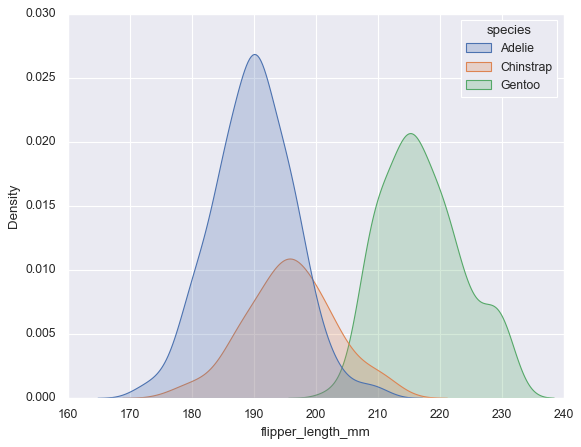

In [14]:
sns.kdeplot(data=penguins, x='flipper_length_mm', hue='species', fill=True);

You can also combine a histogram and a KDE in the same plot using ``sns.histplot()`` with ``kde=True``:

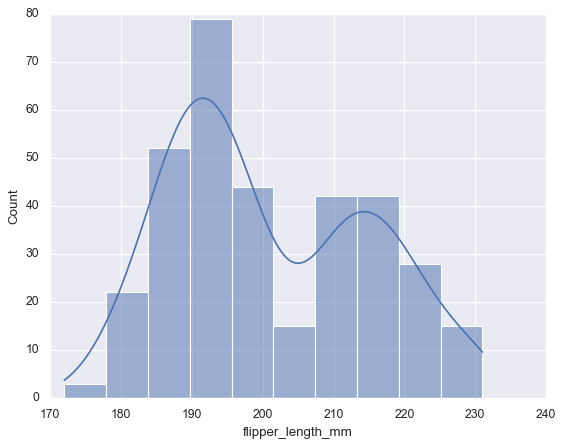

In [15]:
sns.histplot(data=penguins, x='flipper_length_mm', kde=True);

### displot: a figure-level distribution function

``sns.displot()`` is a figure-level function that can produce histograms, KDE plots and ECDF plots. It also supports faceting by additional variables.

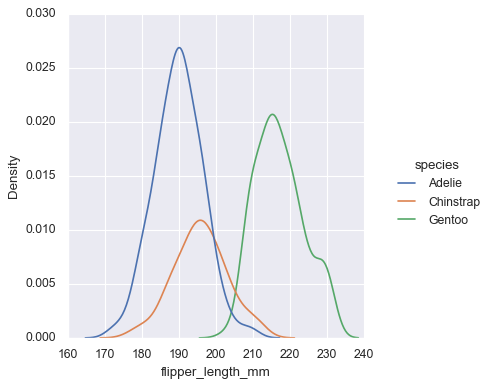

In [16]:
sns.displot(data=penguins, x='flipper_length_mm', hue='species', kind='kde');

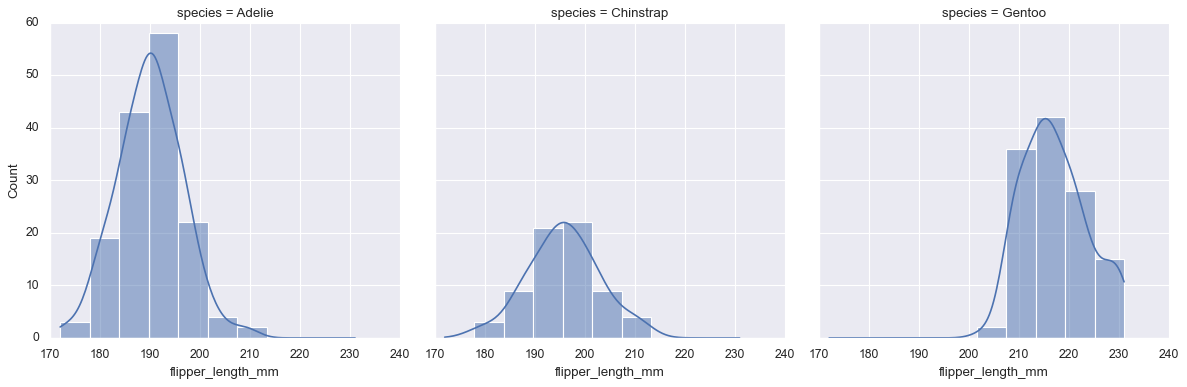

In [17]:
# Faceting by species, showing histograms
sns.displot(data=penguins, x='flipper_length_mm', col='species', kde=True);

## Line charts

Line charts are a good way to visualize time series data. With this type of visualization it is easy to see trends.

The flights dataset contains monthly airline passenger numbers from 1949 to 1960.

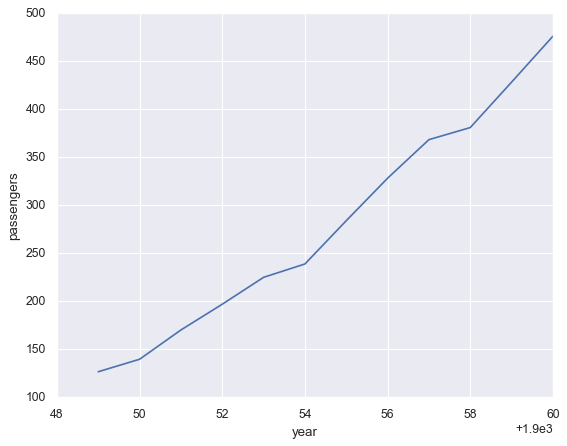

In [18]:
# Aggregate by year to show the overall trend
flights_yearly = flights.groupby('year')['passengers'].mean().reset_index()

sns.lineplot(data=flights_yearly, x='year', y='passengers');

When there are multiple y values for the same x value (e.g. the original monthly data grouped by year), ``sns.lineplot()`` automatically plots the mean and the 95% confidence interval:

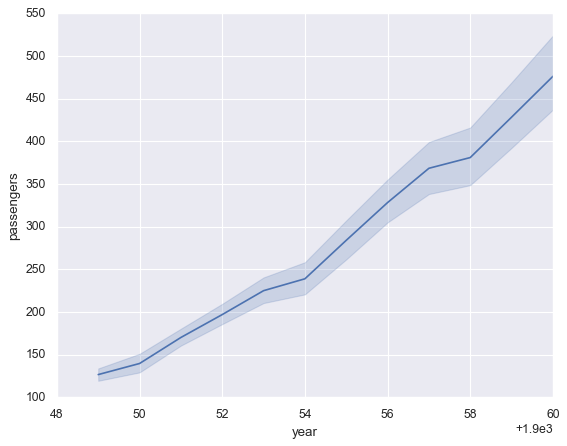

In [19]:
sns.lineplot(data=flights, x='year', y='passengers');

You can also use the ``hue`` parameter to show separate lines for different groups:

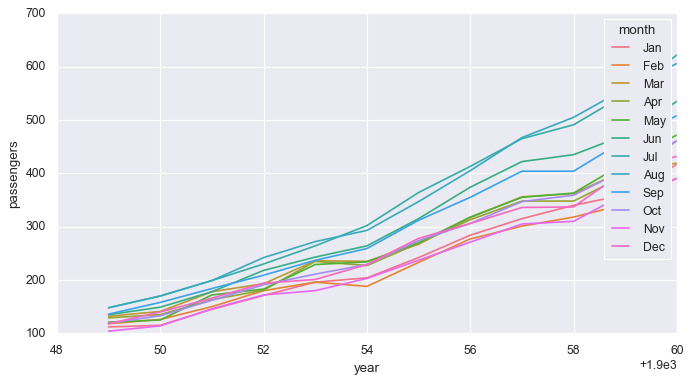

In [20]:
# Show separate lines for each month
plt.figure(figsize=(10, 5))
sns.lineplot(data=flights, x='year', y='passengers', hue='month');

## Bar charts

Bar charts are useful for presenting categorical data where one axis is the category and the other is a measured value. Bar charts should not be confused with histograms.

In seaborn, ``sns.barplot()`` creates bar charts that by default show the mean and 95% confidence interval.

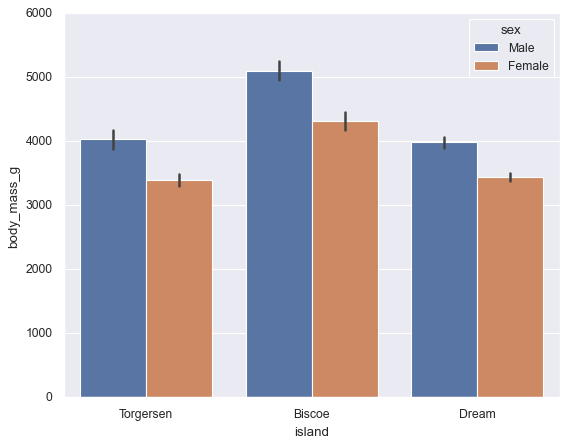

In [21]:
sns.barplot(data=penguins, x='island', y='body_mass_g', hue='sex');

``sns.countplot()`` is a convenience function for bar charts that show the count of observations in each category:

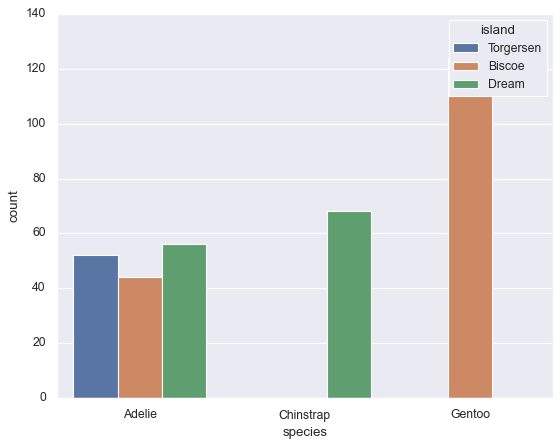

In [22]:
sns.countplot(data=penguins, x='species', hue='island');

## Boxplots

Box plots show the three quartile values of the distribution as well as the range. They are useful for comparing distributions across categories.

The box extends from Q1 to Q3, the line inside the box is the median (Q2), the whiskers extend to 1.5 * IQR, and points beyond that are shown as outliers.

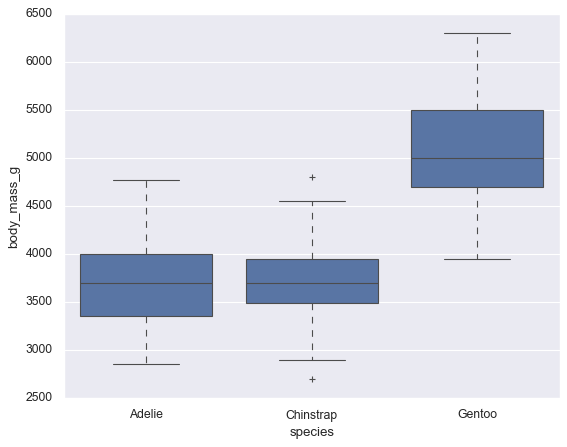

In [23]:
sns.boxplot(data=penguins, x='species', y='body_mass_g');

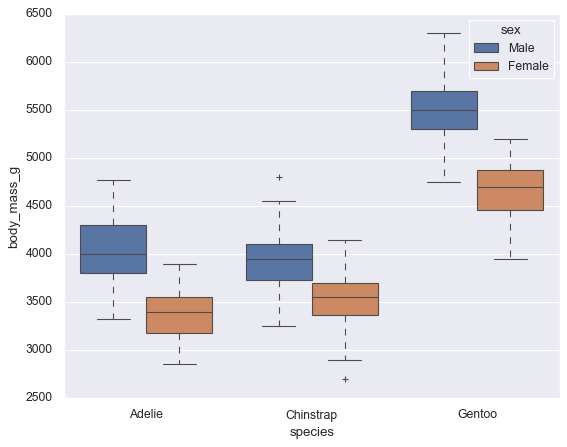

In [24]:
# Adding hue to compare within species
sns.boxplot(data=penguins, x='species', y='body_mass_g', hue='sex');

## Heatmaps

Heatmaps are a good way to see relationships between two variables and their different values. The color describes the magnitude of some measurement.

A common use case is to pivot data into a matrix and then visualize it.

In [25]:
# Pivot the flights data into a year x month matrix
flights_pivot = flights.pivot(index='month', columns='year', values='passengers')
flights_pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


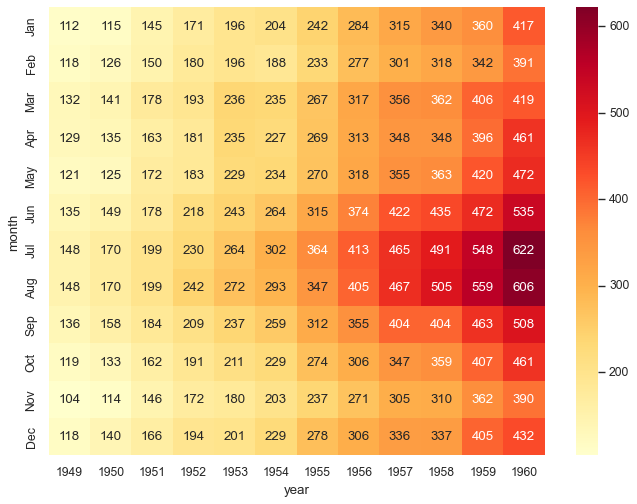

In [27]:
plt.figure(figsize=(10, 7))
sns.heatmap(flights_pivot, annot=True, fmt='d', cmap='YlOrRd');

Heatmaps are also commonly used to visualize correlation matrices:

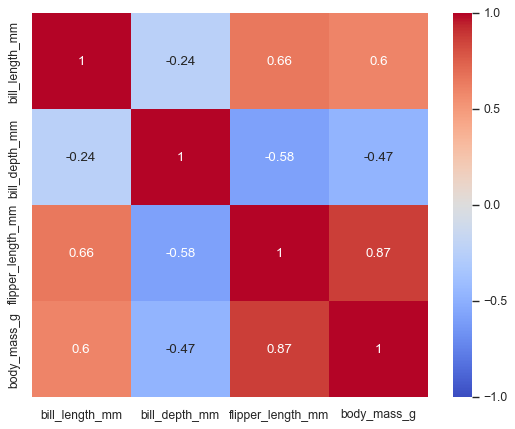

In [28]:
# Compute correlation matrix for numerical columns
corr = penguins.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1);

## Customization

Seaborn provides several ways to customize the look of your plots.

### Themes

Seaborn has five built-in themes: ``darkgrid``, ``whitegrid``, ``dark``, ``white``, and ``ticks``. You can set them using ``sns.set_theme(style=...)``.

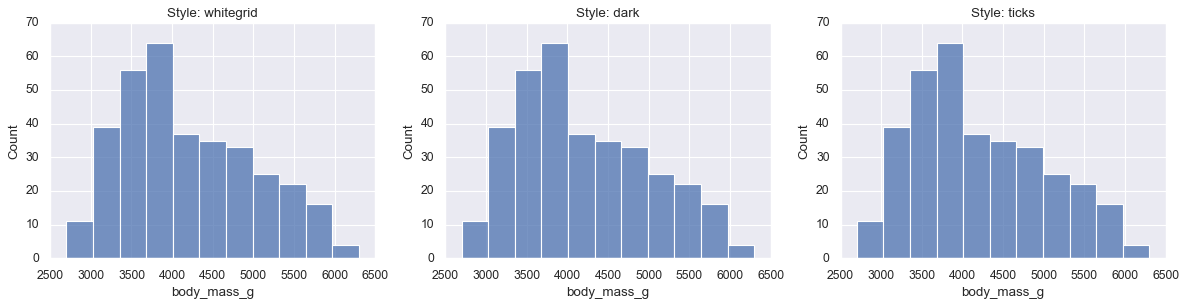

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, style in zip(axes, ['whitegrid', 'dark', 'ticks']):
    with sns.axes_style(style):
        sns.histplot(data=penguins, x='body_mass_g', ax=ax)
        ax.set_title(f'Style: {style}')

plt.tight_layout();

### Figure size and titles

For axes-level functions (e.g. ``histplot``, ``scatterplot``, ``barplot``), you control the figure size with ``plt.figure(figsize=(w, h))`` and add titles with ``plt.title()``. For figure-level functions (e.g. ``relplot``, ``displot``, ``catplot``), you can use the ``height`` and ``aspect`` parameters.

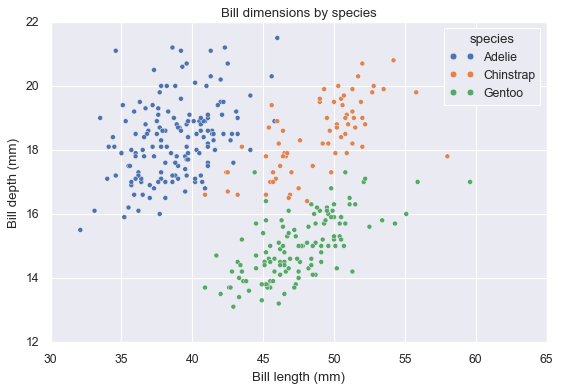

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Bill dimensions by species')
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)');

### Saving figures

You can save any figure to a file using ``plt.savefig()``. The file format is inferred from the file extension.

In [31]:
# Example: save the current figure as a PNG file
# plt.savefig('penguin_scatter.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Further resources

For more information on plotting with Seaborn, see:

- [Seaborn documentation](https://seaborn.pydata.org/)
- [Seaborn tutorial](https://seaborn.pydata.org/tutorial.html)
- [Seaborn example gallery](https://seaborn.pydata.org/examples/index.html)

Other Python libraries for interactive visualizations include [Bokeh](https://bokeh.pydata.org/) and [Plotly](https://plotly.com/python/).